In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
duplicates = df.duplicated().sum()
duplicates

0

In [6]:
df.rename(columns={
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'Score'}, inplace=True)
df.head(2)

,CustomerID,Gender,Age,Income,Score
0,1,Male,19,15,39
1,2,Male,21,15,81


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  200 non-null    int64 
 1   Gender      200 non-null    object
 2   Age         200 non-null    int64 
 3   Income      200 non-null    int64 
 4   Score       200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.describe()

,CustomerID,Age,Income,Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
df.drop('CustomerID', axis=1, inplace=True)
df.head()

,Gender,Age,Income,Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [10]:
gender_counts = df['Gender'].value_counts()
gender_counts

Female    112
Male       88
Name: Gender, dtype: int64

In [11]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Define custom color palettes for better visualizations
palette = sns.color_palette("viridis", 5)
gender_palette = {"Male": "#1f77b4", "Female": "#ff7f0e"}

In [12]:
plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(2, 2)

<Figure size 1440x1152 with 0 Axes>

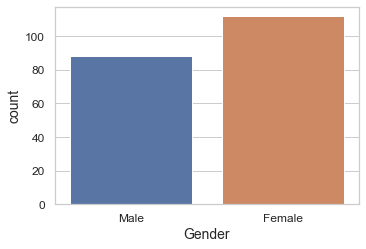

In [13]:
plt.subplot(gs[0, 0])
sns.countplot(x= df.Gender);

Text(0, 0.5, 'Frequency')

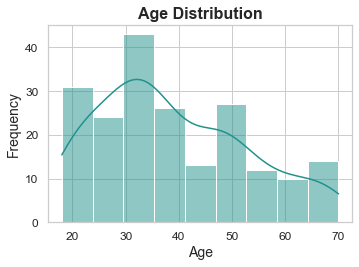

In [48]:
plt.subplot(gs[0, 1])
sns.histplot(df.Age, kde=True, color=palette[2])
plt.title('Age Distribution', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

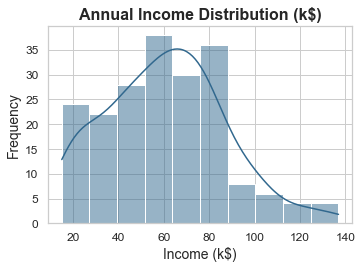

In [15]:
plt.subplot(gs[0, 1])
sns.histplot(df.Income, kde=True, color=palette[1])
plt.title('Annual Income Distribution (k$)', fontweight='bold')
plt.xlabel('Income (k$)')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

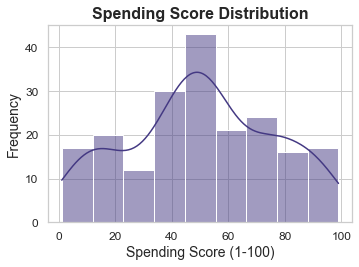

In [16]:
plt.subplot(gs[1, 0])
sns.histplot(df.Score, kde=True, color=palette[0])
plt.title('Spending Score Distribution', fontweight='bold')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')

Text(0, 0.5, 'Income (k$)')

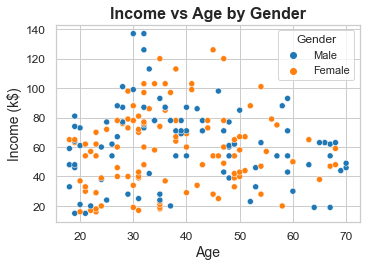

In [17]:
plt.subplot(gs[1, 1])
sns.scatterplot(x='Age', y='Income', hue='Gender', data=df, palette=gender_palette)
plt.title('Income vs Age by Gender', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Income (k$)')

Text(0, 0.5, 'Income (k$)')

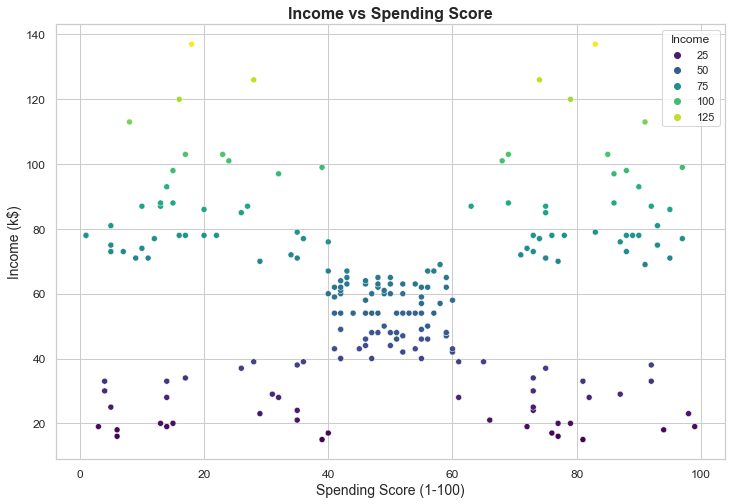

In [18]:
sns.scatterplot(x='Score', y='Income', data=df, hue='Income', palette='viridis')
plt.title('Income vs Spending Score', fontweight='bold')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Income (k$)')

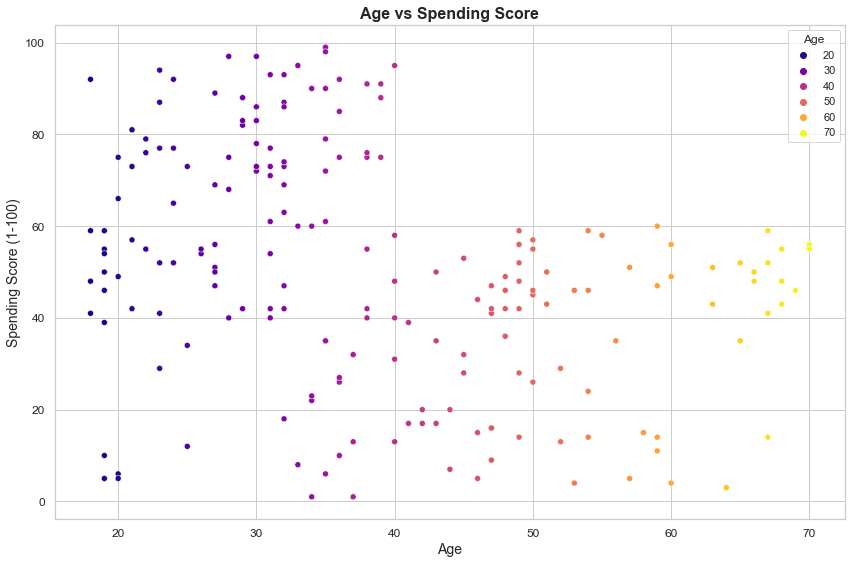

In [20]:
sns.scatterplot(x='Age', y='Score', data=df, hue='Age', palette='plasma')
plt.title('Age vs Spending Score', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

In [21]:
X = df[['Income', 'Score']].values

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

C:\Users\core2duo\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\core2duo\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\core2duo\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\core2duo\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

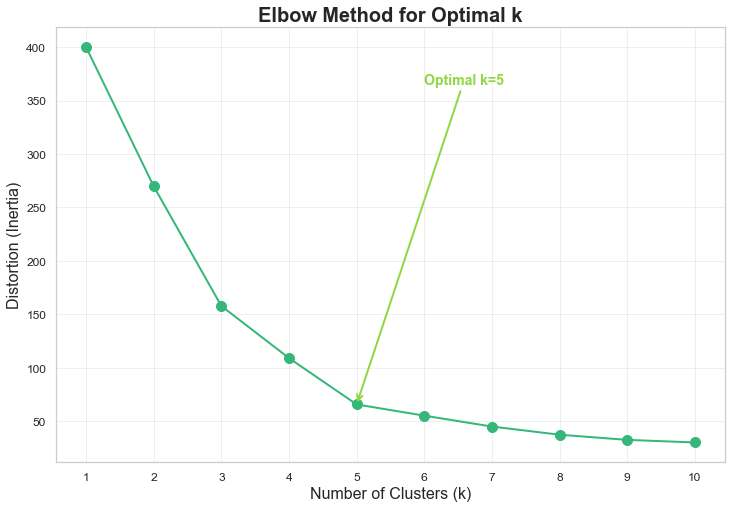

In [24]:
plt.figure(figsize=(12, 8))
plt.plot(k_range, inertia, marker='o', linestyle='-', color=palette[3], linewidth=2, markersize=10)
plt.grid(True, alpha=0.3)
plt.title('Elbow Method for Optimal k', fontsize=20, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=16)
plt.ylabel('Distortion (Inertia)', fontsize=16)
plt.xticks(k_range)
plt.annotate('Optimal k=5', xy=(5, inertia[4]), xytext=(6, inertia[4]+300),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color=palette[4], lw=2), 
             fontsize=14, color=palette[4], fontweight='bold')
plt.show()

In [25]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_pred = kmeans.fit_predict(X_scaled)

C:\Users\core2duo\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [26]:
df['Cluster'] = y_pred
df['Cluster'].value_counts()

0    81
1    39
3    35
4    23
2    22
Name: Cluster, dtype: int64

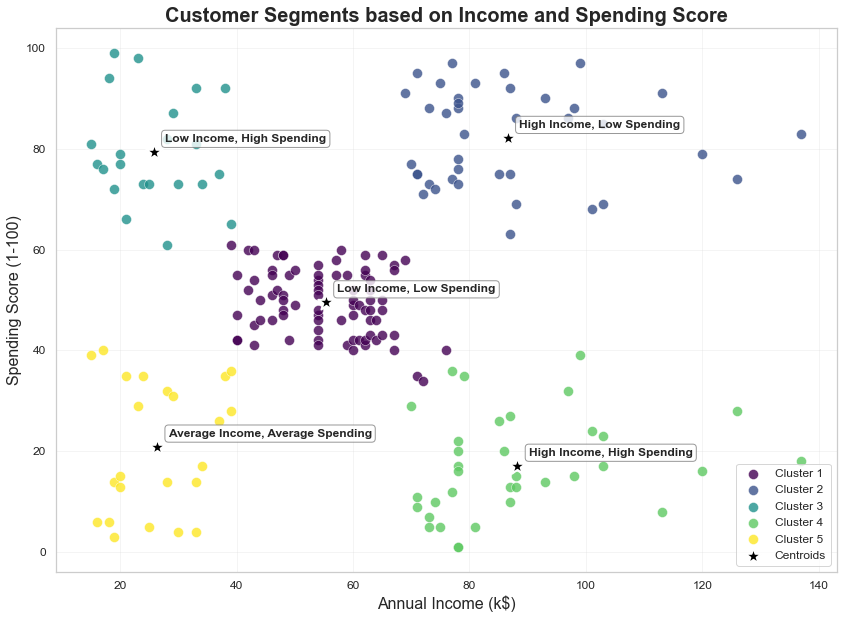

In [33]:
plt.figure(figsize=(14, 10))

custom_cmap = LinearSegmentedColormap.from_list("custom", 
    ["#440154", "#3b528b", "#21918c", "#5ec962", "#fde725"], N=5)
cluster_colors = [custom_cmap(i/4) for i in range(5)]


for i in range(5):
    plt.scatter(X[y_pred == i, 0], X[y_pred == i, 1], 
                s=100, c=[cluster_colors[i]], 
                label=f'Cluster {i+1}', alpha=0.8, edgecolors='w', linewidth=0.5)


centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], 
            s=300, c='black', marker='*', label='Centroids', alpha=1, edgecolors='white', linewidth=2)


plt.title('Customer Segments based on Income and Spending Score', fontsize=20, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=16)
plt.ylabel('Spending Score (1-100)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.2)



annotations = [
    "Low Income, Low Spending",
    "High Income, Low Spending",
    "Low Income, High Spending",
    "High Income, High Spending",
    "Average Income, Average Spending"
]

for i, (x, y) in enumerate(centroids_original):
    plt.annotate(annotations[i], 
                 xy=(x, y), 
                 xytext=(x+2, y+2),
                 fontsize=12, 
                 fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.show()

In [34]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)

C:\Users\core2duo\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [35]:
df['Cluster'] = y_pred
df['Cluster'].value_counts()

0    81
1    39
3    35
4    23
2    22
Name: Cluster, dtype: int64

C:\Users\core2duo\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


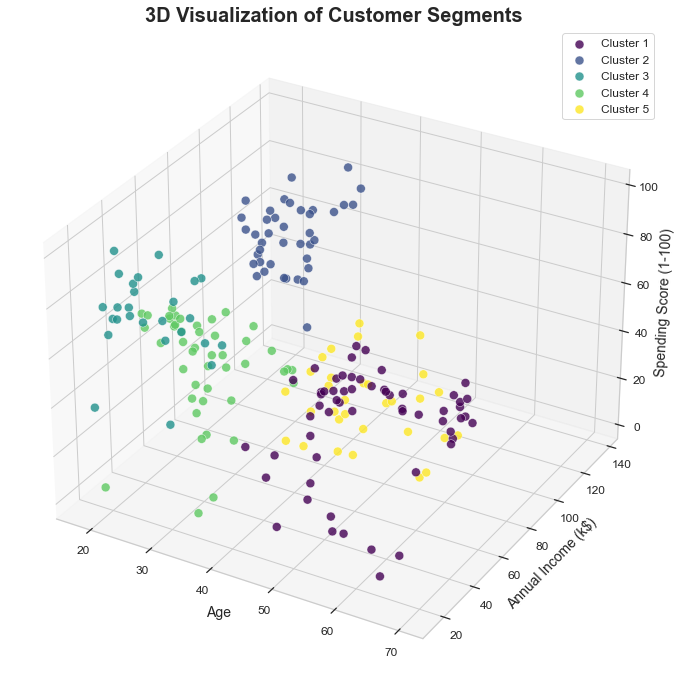

In [46]:
from mpl_toolkits.mplot3d import Axes3D

# Scale all three features
X_3d = df[['Age', 'Income', 'Score']].values
X_3d_scaled = scaler.fit_transform(X_3d)

# Apply K-means to the 3D data
kmeans_3d = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_pred_3d = kmeans_3d.fit_predict(X_3d_scaled)

# Plot 3D clusters
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

for i in range(5):
    ax.scatter(X_3d[y_pred_3d == i, 0], 
               X_3d[y_pred_3d == i, 1], 
               X_3d[y_pred_3d == i, 2],
               s=80, 
               c=[cluster_colors[i]], 
               label=f'Cluster {i+1}', 
               alpha=0.8, 
               edgecolors='w', 
               linewidth=0.5)

ax.set_title('3D Visualization of Customer Segments', fontsize=20, fontweight='bold')
ax.set_xlabel('Age', fontsize=14)
ax.set_ylabel('Annual Income (k$)', fontsize=14)
ax.set_zlabel('Spending Score (1-100)', fontsize=14)
plt.legend(fontsize=12)
plt.show()

In [51]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=5, min_samples=5)
dbscan.fit(X_scaled)

labels = dbscan.labels_

In [50]:
labels

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,
        1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,
        1,  0,  1,  0, -1, -1,  1, -1, -1, -1, -1, -1, -1], dtype=int64)